# Boo Who? · Phase 5: the Owl's brain

The Owl is the AI inside the game. In this notebook we build its brain in Python and ship it to the browser.

1. **One network for any set of questions.** A player can ask any 0 to 4 of the questions (rot, blood, size, glow colour), in any order. Instead of training 16 separate models, we train **one neural network with masked inputs**: every training monster is copied 16 times, each copy hides a different set of answers and tells the network which answers are hidden.
2. **Compare it** with 16 separate logistic regressions and 16 gradient boosted tree models.
3. **Smart questions.** The Owl recommends the question with the highest **expected information gain**: the one that should remove the most uncertainty, on average, before we know the answer.
4. **Explain the answer** with exact **Shapley values**: how much each answered question pushed the Owl towards its pick.
5. **Export to ONNX**, the open standard for trained models, so the exact same network runs in the browser with ONNX Runtime Web (WebAssembly). We check that Python and ONNX give the same numbers.

**Inputs:** `../data/clean/train_clean.csv`, `../web/data/monsters.json`, `../web/data/tells.json`
**Outputs:** `../web/data/owl_brain.onnx`, `../web/data/owl_brain.json`, `../reports/figures/owl_models.png`, `../reports/figures/owl_questions.png`, `../reports/figures/owl_shapley.png`

In [1]:
import json, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix

CLEAN = Path('../data/clean'); WEB = Path('../web/data'); FIGS = Path('../reports/figures')
CLASSES = ['Zombie', 'Witch', 'Ghost', 'Vampire', 'Mummy']
COLORS = ['green', 'grey', 'purple', 'white']
QUESTIONS = ['rot', 'blood', 'height', 'color']
FIELD = {'rot': 'rottingFleshPct', 'blood': 'bloodCoverage', 'height': 'height'}
NUMERIC = ['rot', 'blood', 'height']
SEED = 42
tells = json.loads((WEB / 'tells.json').read_text())

data = pd.read_csv(CLEAN / 'train_clean.csv')
idx_tr, idx_va = train_test_split(np.arange(len(data)), test_size=0.2, stratify=data['class'], random_state=SEED)   # same split as notebooks 02 to 04
train, valid = data.iloc[idx_tr].reset_index(drop=True), data.iloc[idx_va].reset_index(drop=True)
game = pd.DataFrame(json.loads((WEB / 'monsters.json').read_text()))       # the held-out monsters the game uses
for c in COLORS: game[f'color_{c}'] = (game['color'] == c).astype(int)
print(f'{len(train):,} monsters to train on, {len(valid):,} to validate, {len(game):,} held-out game monsters')

29,997 monsters to train on, 7,500 to validate, 7,500 held-out game monsters


## 1. Inputs with a mask

Each monster becomes 11 numbers: 3 scaled measurements (rot, blood, height), 4 one-hot glow colours, and 4 **mask bits** that say which questions were answered. A question that was not asked has its values set to 0 and its mask bit set to 0, so the network can tell "not asked" apart from "average".

In [2]:
SCALE = {q: {'mean': float(train[FIELD[q]].mean()), 'std': float(train[FIELD[q]].std())} for q in NUMERIC}
SLOTS = {'rot': [0], 'blood': [1], 'height': [2], 'color': [3, 4, 5, 6]}
N_IN = 11

def features(df):
    num = [(df[FIELD[q]].values - SCALE[q]['mean']) / SCALE[q]['std'] for q in NUMERIC]
    return np.column_stack(num + [df[f'color_{c}'].values for c in COLORS]).astype(np.float32)

def apply_mask(X, mask):
    Z = X.copy(); bits = np.zeros((len(X), 4), np.float32)
    for i, q in enumerate(QUESTIONS):
        if mask >> i & 1: bits[:, i] = 1
        else: Z[:, SLOTS[q]] = 0
    return np.hstack([Z, bits])

def asked(mask): return [q for i, q in enumerate(QUESTIONS) if mask >> i & 1]
MASKS = range(16)

X_tr, X_va, X_game = features(train), features(valid), features(game)
y_tr = train['class'].map(CLASSES.index).values; y_va = valid['class'].map(CLASSES.index).values; y_game = game['class'].map(CLASSES.index).values
X_aug = np.vstack([apply_mask(X_tr, m) for m in MASKS]); y_aug = np.tile(y_tr, 16)
print('augmented training set:', X_aug.shape)

augmented training set: (479952, 11)


## 2. Train the Owl's brain

In [3]:
t0 = time.time()
brain = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', alpha=1e-4, batch_size=512, max_iter=60,
                      early_stopping=True, n_iter_no_change=6, random_state=SEED)
brain.fit(X_aug, y_aug)
print(f'trained in {time.time() - t0:.0f} s, {brain.n_iter_} epochs, {sum(w.size for w in brain.coefs_) + sum(b.size for b in brain.intercepts_):,} weights')

trained in 20 s, 21 epochs, 3,013 weights


## 3. One network against 16 specialist models

For every set of questions we also train a logistic regression and a gradient boosted tree model that only see those questions. If the single masked network is as good as the specialists, the game can ship one small model instead of 16.

In [4]:
prior = np.bincount(y_tr, minlength=5) / len(y_tr)
rows = []
for m in MASKS:
    cols = [c for q in asked(m) for c in SLOTS[q]]
    p_net = brain.predict_proba(apply_mask(X_va, m))
    if cols:
        p_lr = LogisticRegression(max_iter=3000).fit(X_tr[:, cols], y_tr).predict_proba(X_va[:, cols])
        p_gb = HistGradientBoostingClassifier(random_state=SEED).fit(X_tr[:, cols], y_tr).predict_proba(X_va[:, cols])
    else:
        p_lr = p_gb = np.tile(prior, (len(y_va), 1))
    for name, p in [('Owl network (1 model)', p_net), ('Logistic regression (16 models)', p_lr), ('Gradient boosting (16 models)', p_gb)]:
        rows.append({'mask': m, 'questions': len(asked(m)), 'model': name, 'accuracy': accuracy_score(y_va, p.argmax(1)), 'log_loss': log_loss(y_va, p, labels=range(5))})
comp = pd.DataFrame(rows)
by_k = comp.groupby(['questions', 'model'])[['accuracy', 'log_loss']].mean().unstack('model')
by_k.round(3)

accuracy                                  \
model     Gradient boosting (16 models) Logistic regression (16 models)   
questions                                                                 
0                                 0.399                           0.399   
1                                 0.564                           0.552   
2                                 0.720                           0.703   
3                                 0.827                           0.801   
4                                 0.892                           0.865   

                                                     log_loss  \
model     Owl network (1 model) Gradient boosting (16 models)   
questions                                                       
0                         0.399                         1.490   
1                         0.564                         1.031   
2                         0.719                         0.677   
3                         0.827                         0.429   
4                         0.890                         0.266   

                                                                 
model     Logistic regression (16 models) Owl network (1 model)  
questions                                                        
0                                   1.490                 1.490  
1                                   1.086                 1.035  
2                                   0.756                 0.679  
3                                   0.516                 0.432  
4                                   0.352                 0.273

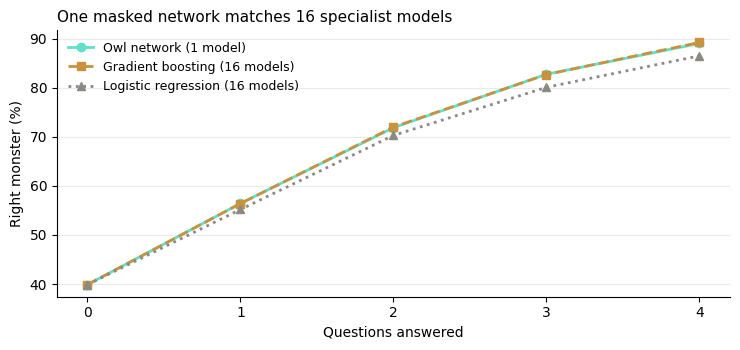

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
styles = {'Owl network (1 model)': ('#5fe0c8', 'o', '-'), 'Gradient boosting (16 models)': ('#c8923f', 's', '--'), 'Logistic regression (16 models)': ('#8a8984', '^', ':')}
for name, (col, mk, ls) in styles.items():
    s = by_k['accuracy'][name]; ax.plot(s.index, s.values * 100, marker=mk, ls=ls, color=col, label=name, lw=2)
ax.set_xticks(range(5)); ax.set_xlabel('Questions answered'); ax.set_ylabel('Right monster (%)')
ax.set_title('One masked network matches 16 specialist models', loc='left', fontsize=11)
ax.spines[['top', 'right']].set_visible(False); ax.legend(frameon=False, fontsize=9); ax.grid(axis='y', alpha=0.25)
fig.tight_layout(); fig.savefig(FIGS / 'owl_models.png', dpi=150); plt.show()

The single network is as accurate as gradient boosting with a separate model for every set of questions, and clearly better than logistic regression. So the game ships **one** network.

## 4. Which question should the Owl recommend?

Before a question is asked we do not know its answer, so the Owl uses the **expected information gain**:

$$\text{gain}(q) = H(\text{now}) - \mathbb{E}_{\text{answer}}\big[H(\text{after asking } q)\big]$$

$H$ is the entropy (in bits) of the network's belief over the 5 monsters. The game shows answers as levels (rot: none, little, some, lots), so the Owl's state is the levels seen so far. For each of the 625 possible states we take the training monsters that match it, run the network with and without the new question, and average. States with fewer than 25 matching monsters back off to the monsters that match all but the last answer.

In [6]:
CUTS = tells['cuts']
def levels(df):
    L = {q: np.digitize(df[FIELD[q]].values, CUTS[q]) for q in NUMERIC}
    L['color'] = df[[f'color_{c}' for c in COLORS]].values.argmax(1)
    return np.column_stack([L[q] for q in QUESTIONS])

def entropy(p): return -(p * np.log2(np.clip(p, 1e-12, 1))).sum(1)
L_tr = levels(train)
P_tr = {m: brain.predict_proba(apply_mask(X_tr, m)) for m in MASKS}      # the network's belief for every training monster and every question set
H_tr = {m: entropy(P_tr[m]) for m in MASKS}

def state_index(obs):          # obs: level per question, or -1 when not asked -> number from 0 to 624
    return int(sum((o + 1) * 5 ** i for i, o in enumerate(obs)))

MIN_ROWS = 25
policy = [None] * 625
for s in range(625):
    obs = [(s // 5 ** i) % 5 - 1 for i in range(4)]
    mask = sum(1 << i for i, o in enumerate(obs) if o >= 0)
    known = [i for i, o in enumerate(obs) if o >= 0]
    match = np.ones(len(train), bool)
    for i in known: match &= L_tr[:, i] == obs[i]
    back = known[:]
    while match.sum() < MIN_ROWS and back:          # back off: forget answers until enough monsters match
        back.pop(); match = np.ones(len(train), bool)
        for i in back: match &= L_tr[:, i] == obs[i]
    h_now = float(H_tr[mask][match].mean())
    gains = [None if mask >> i & 1 else round(h_now - float(H_tr[mask | 1 << i][match].mean()), 4) for i in range(4)]
    policy[s] = {'h': round(h_now, 4), 'gain': gains, 'n': int(match.sum())}

start = policy[0]
pd.Series({q: g for q, g in zip(QUESTIONS, start['gain'])}, name='expected bits removed by the first question').sort_values(ascending=False)

rot       0.9980
blood     0.8983
height    0.4143
color     0.3812
Name: expected bits removed by the first question, dtype: float64

### Does asking smart questions help?

From night 3 the player only gets 3 questions. We simulate an Owl that asks the best question each time (greedy information gain) against an Owl that asks random questions and against the best fixed order, on the held-out game monsters.

In [7]:
L_game = levels(game)
rng = np.random.default_rng(SEED)
P_game = {m: brain.predict_proba(apply_mask(X_game, m)) for m in MASKS}

def play(order_fn, k):
    right = 0
    for n in range(len(game)):
        obs = [-1] * 4; mask = 0
        for _ in range(k):
            i = order_fn(obs, mask); obs[i] = int(L_game[n, i]); mask |= 1 << i
        right += P_game[mask][n].argmax() == y_game[n]
    return right / len(game)

smart = lambda obs, mask: int(np.nanargmax([np.nan if g is None else g for g in policy[state_index(obs)]['gain']]))
randq = lambda obs, mask: int(rng.choice([i for i in range(4) if not mask >> i & 1]))
import itertools
fixed = {order: play(lambda obs, mask, o=order: next(i for i in o if not mask >> i & 1), 3) for order in itertools.permutations(range(4), 3)}
best_fixed = max(fixed, key=fixed.get)
sim = pd.DataFrame({k: {'Smart questions (information gain)': play(smart, k), 'Best fixed order': max(play(lambda obs, mask, o=order: next(i for i in o if not mask >> i & 1), k) for order in itertools.permutations(range(4))) if k < 4 else play(smart, 4), 'Random questions': play(randq, k)} for k in [1, 2, 3, 4]}).T
sim.index.name = 'questions'
print('best fixed order:', ' -> '.join(QUESTIONS[i] for i in best_fixed))
(sim * 100).round(1)

best fixed order: rot -> blood -> color


,Smart questions (information gain),Best fixed order,Random questions
questions,,,
1,66.9,66.9,56.0
2,84.0,84.0,72.2
3,87.9,87.4,83.6
4,90.0,90.0,90.0


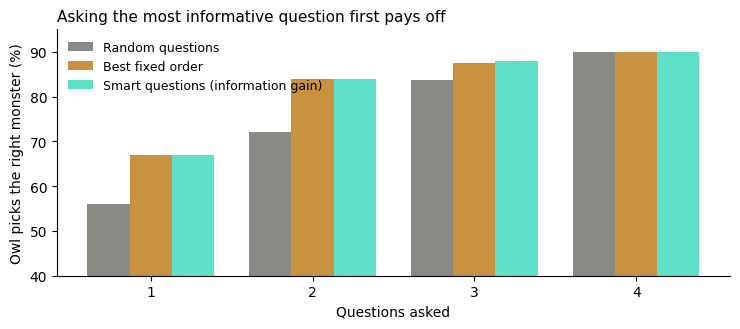

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
x = np.arange(1, 5); w = 0.26
for j, (name, col) in enumerate([('Random questions', '#8a8984'), ('Best fixed order', '#c8923f'), ('Smart questions (information gain)', '#5fe0c8')]):
    ax.bar(x + (j - 1) * w, sim[name] * 100, w, color=col, label=name)
ax.set_xticks(x); ax.set_xlabel('Questions asked'); ax.set_ylabel('Owl picks the right monster (%)'); ax.set_ylim(40, 95)
ax.set_title('Asking the most informative question first pays off', loc='left', fontsize=11)
ax.spines[['top', 'right']].set_visible(False); ax.legend(frameon=False, fontsize=9, loc='upper left')
fig.tight_layout(); fig.savefig(FIGS / 'owl_questions.png', dpi=150); plt.show()

## 5. Why did the Owl pick that monster? Exact Shapley values

With 4 questions there are only 16 question sets, and the network can answer every one of them. So we can compute **exact** Shapley values instead of an approximation: the contribution of a question is its average effect on the probability of the picked monster, over every order in which the questions could have been asked. The game runs the same calculation live to explain the Owl's final answer.

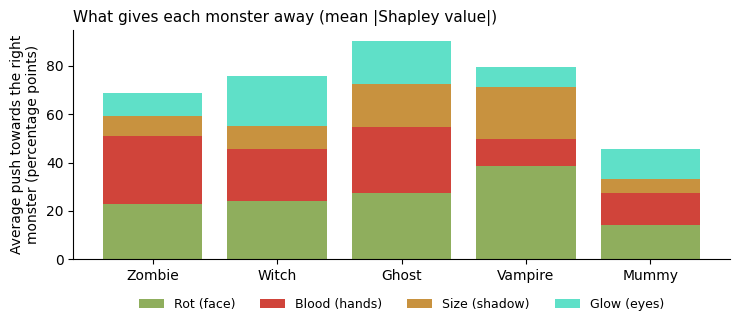

,rot,blood,height,color
class,,,,
Zombie,23.0,27.9,8.2,9.6
Witch,24.2,21.4,9.4,20.9
Ghost,27.5,27.1,17.8,17.8
Vampire,38.5,11.1,21.8,8.0
Mummy,14.0,13.4,5.7,12.7


In [9]:
from math import factorial
def shapley(P, n, cls, full_mask):
    # P[mask] = probabilities for every monster; returns contribution of each asked question to p(cls)
    players = [i for i in range(4) if full_mask >> i & 1]; k = len(players); phi = np.zeros(4)
    for i in players:
        others = [j for j in players if j != i]
        for r in range(len(others) + 1):
            for sub in itertools.combinations(others, r):
                s = sum(1 << j for j in sub)
                wgt = factorial(r) * factorial(k - r - 1) / factorial(k)
                phi[i] += wgt * (P[s | 1 << i][n, cls] - P[s][n, cls])
    return phi

phis = np.array([shapley(P_game, n, y_game[n], 15) for n in range(len(game))])
imp = pd.DataFrame(np.abs(phis), columns=QUESTIONS); imp['class'] = game['class'].values
by_class = imp.groupby('class')[QUESTIONS].mean().loc[CLASSES]
names = {'rot': 'Rot (face)', 'blood': 'Blood (hands)', 'height': 'Size (shadow)', 'color': 'Glow (eyes)'}

fig, ax = plt.subplots(figsize=(7.5, 3.4))
cols = ['#8fae5d', '#d0443a', '#c8923f', '#5fe0c8']; bottom = np.zeros(len(CLASSES))
for q, col in zip(QUESTIONS, cols):
    ax.bar(CLASSES, by_class[q] * 100, bottom=bottom * 100, color=col, label=names[q]); bottom += by_class[q].values
ax.set_ylabel('Average push towards the right\nmonster (percentage points)'); ax.spines[['top', 'right']].set_visible(False)
ax.set_title('What gives each monster away (mean |Shapley value|)', loc='left', fontsize=11); ax.legend(frameon=False, fontsize=9, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(); fig.savefig(FIGS / 'owl_shapley.png', dpi=150); plt.show()
(by_class * 100).round(1)

In [10]:
# one example: a Witch from the game
n = int(np.where(y_game == 1)[0][0]); p = P_game[15][n]
print(game.loc[n, ['class', 'rottingFleshPct', 'bloodCoverage', 'height', 'color']].to_dict())
print('Owl belief:', {c: round(float(v), 3) for c, v in zip(CLASSES, p)})
print('why (Shapley, towards Witch):', {q: round(float(v), 3) for q, v in zip(QUESTIONS, shapley(P_game, n, 1, 15))})
print('check: prior + contributions =', round(P_game[0][n, 1] + shapley(P_game, n, 1, 15).sum(), 4), 'equals', round(p[1], 4))

{'class': 'Witch', 'rottingFleshPct': 20.54, 'bloodCoverage': 16.198, 'height': 61.273957, 'color': 'purple'}
Owl belief: {'Zombie': 0.008, 'Witch': 0.98, 'Ghost': 0.0, 'Vampire': 0.0, 'Mummy': 0.012}
why (Shapley, towards Witch): {'rot': 0.283, 'blood': 0.162, 'height': 0.098, 'color': 0.235}
check: prior + contributions = 0.9803 equals 0.9803


## 6. Export to ONNX and check it gives the same answers

`skl2onnx` converts the trained scikit-learn network into an ONNX graph. The game loads it with **ONNX Runtime Web**, which runs it in WebAssembly. We also save the raw weights, so the game can fall back to a small JavaScript version if WebAssembly is blocked. Both must match Python.

In [11]:
from skl2onnx import to_onnx
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as ort

onx = to_onnx(brain, initial_types=[('monster', FloatTensorType([None, N_IN]))], options={id(brain): {'zipmap': False}}, target_opset=17)
(WEB / 'owl_brain.onnx').write_bytes(onx.SerializeToString())
sess = ort.InferenceSession(str(WEB / 'owl_brain.onnx'), providers=['CPUExecutionProvider'])
print('inputs:', [(i.name, i.shape) for i in sess.get_inputs()], 'outputs:', [o.name for o in sess.get_outputs()])

X_check = np.vstack([apply_mask(X_game[:500], m) for m in MASKS])
p_onnx = sess.run(['probabilities'], {'monster': X_check})[0]
p_py = brain.predict_proba(X_check)

def forward(x):             # the same maths the JavaScript fallback uses
    a = x
    for i, (W, b) in enumerate(zip(brain.coefs_, brain.intercepts_)):
        a = a @ W + b
        if i < len(brain.coefs_) - 1: a = np.maximum(a, 0)
    e = np.exp(a - a.max(1, keepdims=True)); return e / e.sum(1, keepdims=True)
p_js = forward(X_check)
parity = {'onnx_vs_python': float(np.abs(p_onnx - p_py).max()), 'fallback_vs_python': float(np.abs(p_js - p_py).max())}
print({k: f'{v:.1e}' for k, v in parity.items()}, 'on', len(X_check), 'inputs')
assert max(parity.values()) < 1e-4
print(f"model file: {(WEB / 'owl_brain.onnx').stat().st_size / 1024:.1f} KB")

inputs: [('monster', [None, 11])] outputs: ['label', 'probabilities']


{'onnx_vs_python': '2.4e-07', 'fallback_vs_python': '0.0e+00'} on 8000 inputs
model file: 13.0 KB


## 7. Save everything the game needs

In [12]:
full = P_game[15].argmax(1)
acc_k = comp[comp.model == 'Owl network (1 model)'].groupby('questions')['accuracy'].mean()
brain_json = {
    'classes': CLASSES, 'questions': QUESTIONS, 'colors': COLORS, 'field': FIELD, 'scale': SCALE, 'slots': SLOTS, 'n_inputs': N_IN,
    'layout': ['rot', 'blood', 'height'] + [f'color_{c}' for c in COLORS] + [f'asked_{q}' for q in QUESTIONS],
    'train_prior': prior.round(5).tolist(),
    'weights': [{'W': np.round(W, 6).tolist(), 'b': np.round(b, 6).tolist()} for W, b in zip(brain.coefs_, brain.intercepts_)],
    'policy': policy,
    'stats': {
        'n_train': int(len(train)), 'n_augmented': int(len(X_aug)), 'n_game': int(len(game)), 'epochs': int(brain.n_iter_),
        'n_weights': int(sum(w.size for w in brain.coefs_) + sum(b.size for b in brain.intercepts_)),
        'layers': [N_IN, 64, 32, 5], 'onnx_kb': round((WEB / 'owl_brain.onnx').stat().st_size / 1024, 1), 'parity': parity,
        'accuracy_by_questions': {name: [round(float(v), 4) for v in by_k['accuracy'][name].values] for name in styles},
        'policy_sim': {name: [round(float(v), 4) for v in sim[name].values] for name in sim.columns},
        'best_fixed_order': [QUESTIONS[i] for i in best_fixed],
        'shapley_by_class': {c: [round(float(v), 4) for v in by_class.loc[c].values] for c in CLASSES},
        'game_accuracy_all4': round(float((full == y_game).mean()), 4),
        'confusion_all4': confusion_matrix(y_game, full, labels=range(5)).tolist(),
    },
}
(WEB / 'owl_brain.json').write_text(json.dumps(brain_json, separators=(',', ':')))
print(f"owl_brain.json: {(WEB / 'owl_brain.json').stat().st_size / 1024:.0f} KB")
print(json.dumps(brain_json['stats'], indent=1)[:1500])

owl_brain.json: 92 KB
{
 "n_train": 29997,
 "n_augmented": 479952,
 "n_game": 7500,
 "epochs": 21,
 "n_weights": 3013,
 "layers": [
  11,
  64,
  32,
  5
 ],
 "onnx_kb": 13.0,
 "parity": {
  "onnx_vs_python": 2.384185791015625e-07,
  "fallback_vs_python": 0.0
 },
 "accuracy_by_questions": {
  "Owl network (1 model)": [
   0.3988,
   0.5642,
   0.7186,
   0.8274,
   0.8903
  ],
  "Gradient boosting (16 models)": [
   0.3988,
   0.564,
   0.7199,
   0.8269,
   0.8923
  ],
  "Logistic regression (16 models)": [
   0.3988,
   0.5519,
   0.7028,
   0.8008,
   0.8649
  ]
 },
 "policy_sim": {
  "Smart questions (information gain)": [
   0.6695,
   0.84,
   0.8792,
   0.9001
  ],
  "Best fixed order": [
   0.6695,
   0.84,
   0.8741,
   0.9001
  ],
  "Random questions": [
   0.5601,
   0.7216,
   0.8363,
   0.9001
  ]
 },
 "best_fixed_order": [
  "rot",
  "blood",
  "color"
 ],
 "shapley_by_class": {
  "Zombie": [
   0.2304,
   0.2791,
   0.0824,
   0.0959
  ],
  "Witch": [
   0.242,
   0.2143

## Result

- **One masked neural network** (11 → 64 → 32 → 5) handles every combination of questions and is as accurate as 16 separate gradient boosted models.
- **Smart questions:** choosing the question with the highest expected information gain beats random questions, most of all when the player only has 2 or 3 questions.
- **Explanations:** exact Shapley values show which answer pushed the Owl to its pick, and they add up exactly to the final probability.
- **Deployment:** the network is exported to **ONNX** and runs in the browser with ONNX Runtime Web. Python, ONNX and the JavaScript fallback agree to better than 0.0001.

In the game: the Owl recommends questions by information gain, explains its final answer with Shapley values, makes its own guess from the same questions you asked (You vs the Owl), and the **AI Lab** screen lets you try the network live.